# Calculating catches from gridded DBPM outputs
**Author**: Denisse Fierro Arcos  
**Date**: 2025-02-06  

In this notebook, we will calculate catches from gridded DBPM outputs.

## Loading relevant libraries

In [1]:
import os
os.chdir('/g/data/vf71/la6889/lme_scale_calibration_ISMIP3a/new_workflow')
import useful_functions as uf
from glob import glob
import xarray as xr
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import cartopy.crs as ccrs
import cartopy.feature as cft
from dask.distributed import Client

## Start a cluster for parallelisation

In [2]:
client = Client(threads_per_worker = 1)

## Defining basic variables to run gridded DBPM

In [2]:
#Name of region and model resolution
region = 'fao-58'
model_res = '1deg'

#Defining input and output folders
base_folder = '/g/data/vf71/la6889/dbpm_inputs/east_antarctica'
gridded_inputs = os.path.join(base_folder, 'gridded_params', model_res)
gridded_outputs = os.path.join(base_folder, 'run_fishing', model_res)
outputs_folder = os.path.join(base_folder, 'gridded_dbpm_outputs', model_res)

#Ensure outputs folder exists
os.makedirs(outputs_folder, exist_ok = True)

## Loading gridded parameters and gridded inputs

In [3]:
#Gridded DBPM parameters
gridded_params = json.load(open(
    os.path.join(gridded_inputs, f'dbpm_gridded_size_params_{region}_python.json')))

#Mortality from fishing (predators and detritivores)
fish_mort_det = xr.open_zarr(glob(
    os.path.join(gridded_inputs, 'fish-mort-det*'))[0])['fish_mort_det']
fish_mort_pred = xr.open_zarr(glob(
    os.path.join(gridded_inputs, 'fish-mort-pred*'))[0])['fish_mort_pred']

#Effort - Only initialisation time step
effort_init = xr.open_zarr(glob(
    os.path.join(gridded_inputs, 'effort_spinup*'))[0])['effort'].isel(time = 0)

#Size class bins
log10_size_bins_mat = xr.open_zarr('outputs/log10_size_bins_matrix.zarr/')['size_bins']
size_bin_vals = 10**log10_size_bins_mat

#Area - to be used for masking land areas
area = xr.open_zarr(glob(os.path.join(base_folder, 'gridded', model_res, 
                                      '*areacello*'))[0])['cellareao']

## Loading gridded DBPM outputs 

In [4]:
predators = xr.open_mfdataset(glob(
    os.path.join(gridded_outputs, 'predators*')))['predators']

detritivores = xr.open_mfdataset(glob(
    os.path.join(gridded_outputs, 'detritivores*')))['detritivores']

effort = xr.open_mfdataset(glob(os.path.join(gridded_outputs, 'effort*')))['effort']

#Add initial effort values
effort = xr.concat([effort_init, effort], dim = 'time')

## Calculate fishing mortality 

In [5]:
fishing_mort_pred = fish_mort_pred*effort
fishing_mort_det = fish_mort_det*effort 

## Calculates catches per time step and size class
`fishing_mort_pred` and `fishing_mort_det` are set to zero outside the sizes for each class, so there is no need to apply a mask here.

In [6]:
catch_pred = fishing_mort_pred*predators*size_bin_vals
catch_det = fishing_mort_det*detritivores*size_bin_vals

## Calculate pelagic predator and benthic detritivore catches from DBPM outputs

In [7]:
# We calculate total catches for detritivores and predators 
# That is we add catches across all fished size classes
tot_catch_pred = (catch_pred*gridded_params['log_size_increase']).sum('size_class')
tot_catch_det = (catch_det*gridded_params['log_size_increase']).sum('size_class')

### Calculate mean decadal catches

In [8]:
#Predator catches
mean_catch_pred_dec = uf.decadal_catches(
    tot_catch_pred, area, name = 'catch_predators',
    attrs = {'units': 'g*decade-1*m-2', 
             'long_name': 'mean predators biomass caught per decade'})

#Detritivore catches
mean_catch_det_dec = uf.decadal_catches(
    tot_catch_det, area, name = 'catch_detritivores',
    attrs = {'units': 'g*decade-1*m-2', 
             'long_name': 'mean detritivores biomass caught per decade'})

#Total catches
sum_catch_dec = mean_catch_pred_dec + mean_catch_det_dec
sum_catch_dec.name = 'catch_total'
sum_catch_dec = sum_catch_dec.assign_attrs({'units': 'g*decade-1*m-2', 
                                            'long_name': 'mean biomass caught per decade'})

#Save catches in a single dataset
mean_catch_dec = xr.Dataset(data_vars = {'catch_det': mean_catch_det_dec,
                                         'catch_pred': mean_catch_pred_dec,
                                         'catch_sum': sum_catch_dec})

### Saving catches

In [125]:
#Get start and end decade
s_dec = str(mean_catch_dec.decade.values.min())
e_dec = str(mean_catch_dec.decade.values.max())

#Create filename to save results
fout = os.path.join(outputs_folder,
                    f'mean_decadal_catches_{model_res}_{region}_{s_dec}_{e_dec}.nc')

mean_catch_dec.to_netcdf(fout)

## Plotting decadal mean catches

## Weddell Sea

### Detritivores

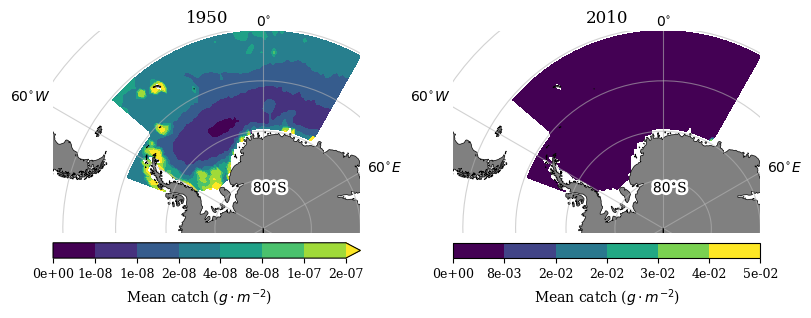

In [10]:
fig, ax = plt.subplots(1, 2, figsize = [8, 9.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_det'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 1.25e-8, 1.5e-8, 2e-8, 4e-8, 8e-8, 1.2e-7, 2.4e-7],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_det'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  # levels = [0, 8e-5, 1e-4, 1.5e-4, 2e-4, 3e-4],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(-0.14, 0.65, '$60^{\circ}W$', transform = a.transAxes, fontsize = 10)
    a.text(1.02, 0.3, '$60^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.66, 1.02, '$0^{\circ}$', transform = a.transAxes, fontsize = 10)
    a.text(0.65, 0.2, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_det_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

### Predators

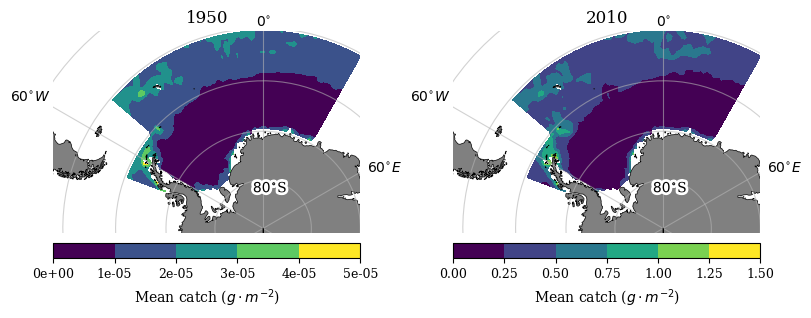

In [11]:
fig, ax = plt.subplots(1, 2, figsize = [8, 9.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_pred'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_pred'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(-0.14, 0.65, '$60^{\circ}W$', transform = a.transAxes, fontsize = 10)
    a.text(1.02, 0.3, '$60^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.66, 1.02, '$0^{\circ}$', transform = a.transAxes, fontsize = 10)
    a.text(0.65, 0.2, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_pred_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

### Total (predators + detritivores)

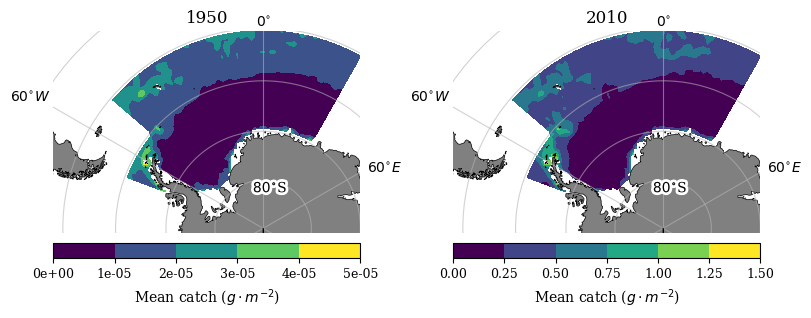

In [12]:
fig, ax = plt.subplots(1, 2, figsize = [8, 9.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_sum'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_sum'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(-0.14, 0.65, '$60^{\circ}W$', transform = a.transAxes, fontsize = 10)
    a.text(1.02, 0.3, '$60^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.66, 1.02, '$0^{\circ}$', transform = a.transAxes, fontsize = 10)
    a.text(0.65, 0.2, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_sum_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

## Calculate mean yearly catches from DBPM outputs (time series)
To make results comparable to outputs from the non-spatial DBPM, we will calculate the mean catches per grid cell and per year.

In [9]:
# We can now calculate the total catch
total_catch = tot_catch_det+tot_catch_pred
total_catch.name = 'mean_catch'

# Finally we calculate the mean yearly catch
total_catch = total_catch.groupby('time.year').mean(('time', 'lat', 'lon'))

# Transforming to data frame
mean_catch = total_catch.to_pandas().reset_index()
# Adding units 
mean_catch['units'] = 'g*year-1*m-2'

## Saving mean catches

In [ ]:
# Getting min and max year from data
min_yr = str(mean_catch.year.min())
max_yr = str(mean_catch.year.max())

# Creating name for file 
out_name = f'mean_year_catch_dbpm_{model_res}_{region}_{min_yr}-{max_yr}.parquet'

# Saving in output folder
mean_catch.to_parquet(os.path.join(outputs_folder, out_name))

## Plotting DBPM catch estimates against observations
We will compare estimatedand observed catches between 1950 and 2010.

In [10]:
# Subsetting DBPM estimates
mean_catch_dbpm = mean_catch[mean_catch.year >= 1950]

# Loading observed catches
hist_catch = pd.read_parquet(glob(os.path.join(base_folder, 'monthly_weighted', 
                                               model_res, '*effort-catch*'))[0])
# Transform catches from tonnes to g per m2
hist_catch['catch_g_m2'] = hist_catch.catch_tonnes_area_m2*1e6

# Loading estimated catches from non-spatial DBPM
mean_catch_non_spatial = pd.read_parquet(
    glob(os.path.join(base_folder, 'run_nonspatial', model_res, 
                      'dbpm_nonspatial*'))[0])
#Keep data from 1950 onwards
mean_catch_non_spatial = mean_catch_non_spatial[mean_catch_non_spatial.year >= 1950]

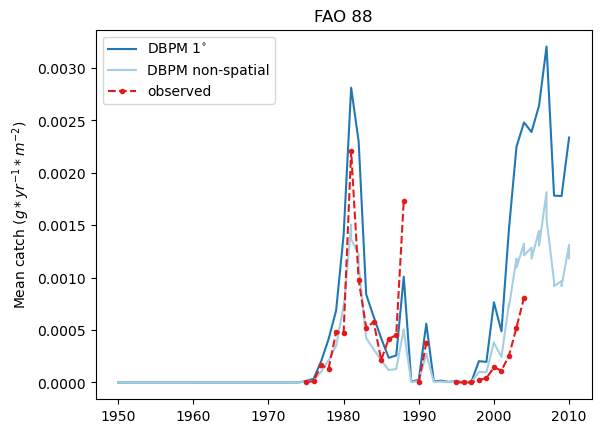

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)
mean_catch_dbpm.plot(x = 'year', y = 'mean_catch', ax = ax, 
                     color = '#1f78b4', label = 'DBPM $1^{\circ}$')
mean_catch_non_spatial.plot(x = 'year', y = 'total_catch', ax = ax, ls = '-',
                            color = '#a6cee3', label = 'DBPM non-spatial')
hist_catch.plot(x = 'year', y = 'catch_g_m2', ax = ax, ls = '--',
                marker = 'o', label = 'observed', color = '#e31a1c',
                markersize = 3)
plt.ylabel('Mean catch ($g*yr^{-1}*m^{-2}$)')
plt.xlabel(None)
plt.title(region.replace('-', ' ').upper())

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_catches_ts_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

## Maps for East Antarctica

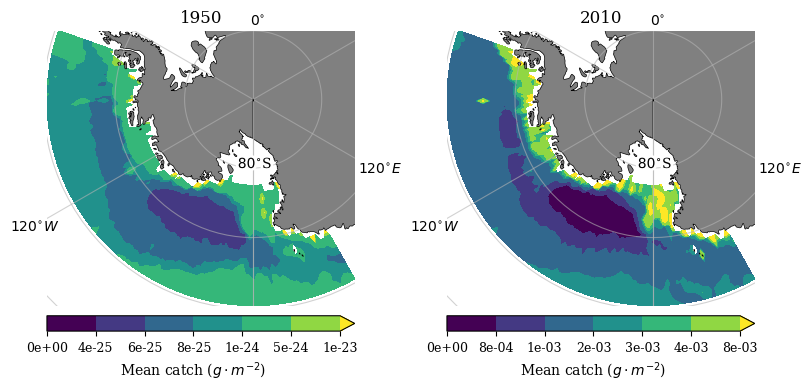

In [11]:
fig, ax = plt.subplots(1, 2, figsize = [8, 9.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_det'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 4e-25, 6e-25, 8e-25, 1e-24, 5e-24, 1e-23],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_det'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 8e-4, 1e-3, 2e-3, 3e-3, 4e-3, 8e-3],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(-0.12, 0.27, '$120^{\circ}W$', transform = a.transAxes, fontsize = 10)
    a.text(1.01, 0.48, '$120^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.66, 1.02, '$0^{\circ}$', transform = a.transAxes, fontsize = 10)
    a.text(0.62, 0.5, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_det_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

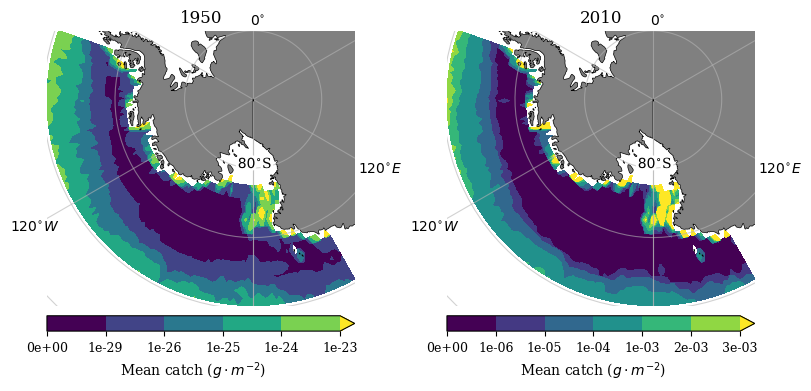

In [12]:
fig, ax = plt.subplots(1, 2, figsize = [8, 9.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_pred'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                   levels = [0, 1e-29, 1e-26, 1e-25, 1e-24, 1e-23],
                                                                   add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_pred'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                   levels = [0, 1e-6, 1e-5, 1e-4, 1e-3, 2e-3, 3e-3],
                                                                   add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(-0.12, 0.27, '$120^{\circ}W$', transform = a.transAxes, fontsize = 10)
    a.text(1.01, 0.48, '$120^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.66, 1.02, '$0^{\circ}$', transform = a.transAxes, fontsize = 10)
    a.text(0.62, 0.5, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_pred_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

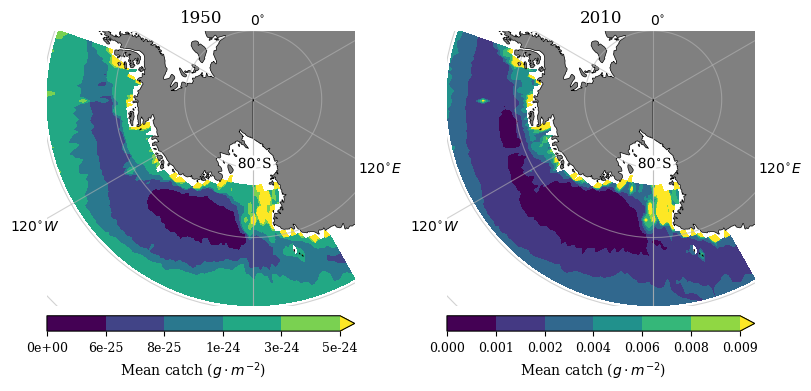

In [13]:
fig, ax = plt.subplots(1, 2, figsize = [8, 9.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_sum'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 6e-25, 8e-25, 1e-24, 3e-24, 5e-24],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_sum'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 9e-3, 8e-3, 6e-3, 4e-3, 2e-3, 1e-3],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(-0.12, 0.27, '$120^{\circ}W$', transform = a.transAxes, fontsize = 10)
    a.text(1.01, 0.48, '$120^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.66, 1.02, '$0^{\circ}$', transform = a.transAxes, fontsize = 10)
    a.text(0.62, 0.5, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_sum_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

## Maps for West Antarctica

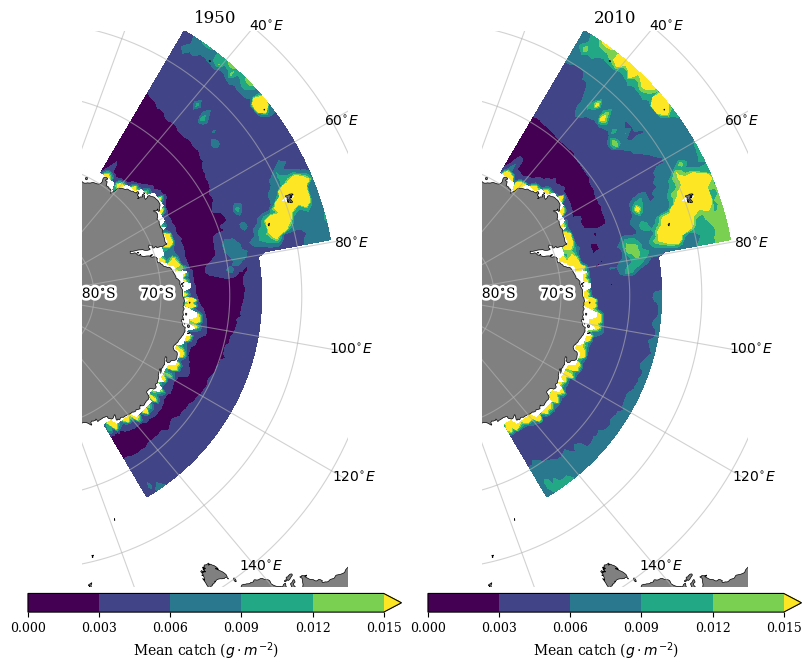

In [126]:
fig, ax = plt.subplots(1, 2, figsize = [8, 6.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_det'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 3e-3, 6e-3, 9e-3, 12e-3, 15e-3],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_det'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 3e-3, 6e-3, 9e-3, 12e-3, 15e-3],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(0.63, 1, '$40^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.91, 0.83, '$60^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.95, 0.61, '$80^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.93, 0.42, '$100^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.94, 0.19, '$120^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.59, 0.03, '$140^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0, 0.52, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])
    a.text(0.22, 0.52, '$70^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_det_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

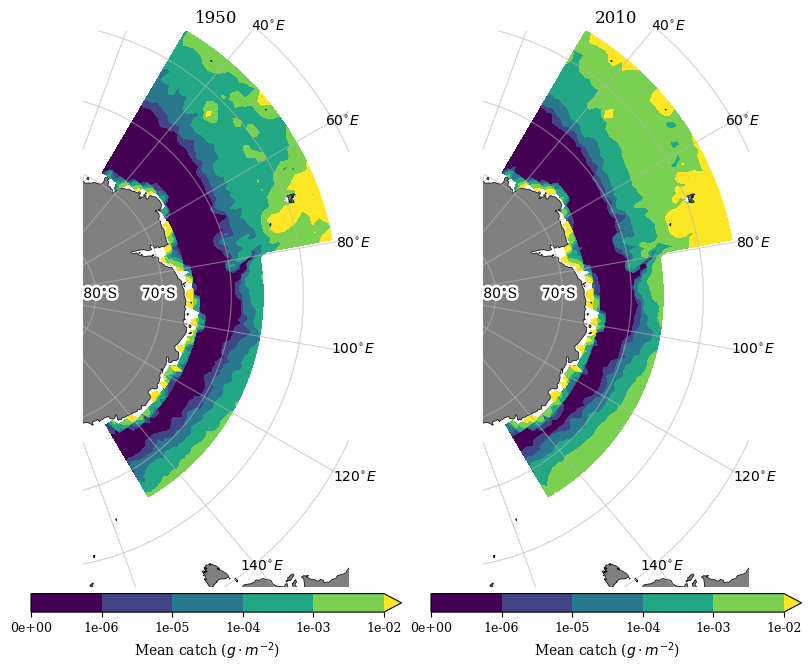

In [93]:
fig, ax = plt.subplots(1, 2, figsize = [8, 6.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_pred'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                   levels = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
                                                                   add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_pred'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                   levels = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
                                                                   add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01, format = '%.0e')
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(0.63, 1, '$40^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.91, 0.83, '$60^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.95, 0.61, '$80^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.93, 0.42, '$100^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.94, 0.19, '$120^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.59, 0.03, '$140^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0, 0.52, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])
    a.text(0.22, 0.52, '$70^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_pred_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)

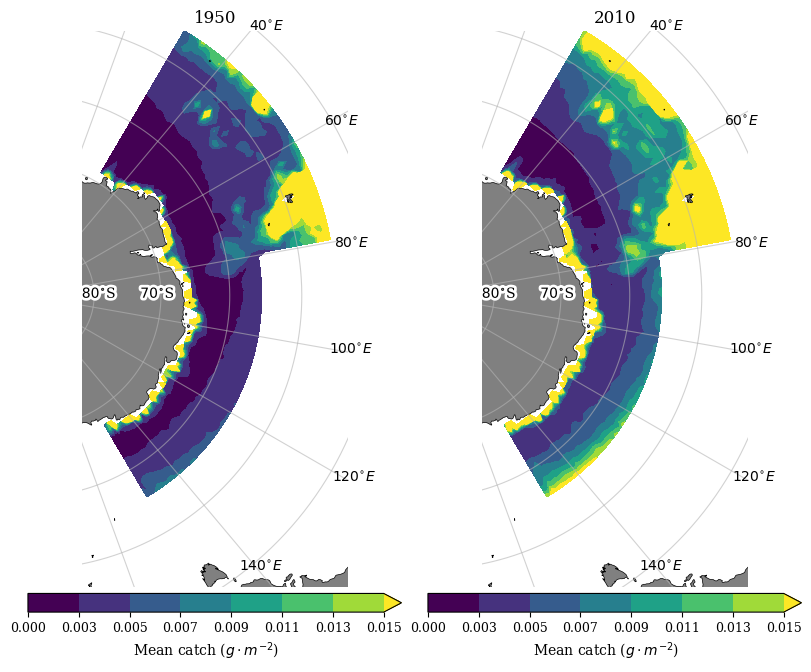

In [106]:
fig, ax = plt.subplots(1, 2, figsize = [8, 6.6], layout = 'constrained', 
                      subplot_kw = {'projection': ccrs.SouthPolarStereo()})

#Set font family and font size for the entire graph
plt.rcParams['font.family'] = 'serif'

#Land mask
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', 
                                   facecolor = 'gray', linewidth = 0.5)


p1 = mean_catch_dec['catch_sum'].sel(decade = 1950).plot.contourf(ax = ax[0], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 3e-3, 5e-3, 7e-3, 9e-3, 11e-3, 13e-3, 15e-3],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p1, ax = ax[0], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[0].title.set_text('1950')

p2 = mean_catch_dec['catch_sum'].sel(decade = 2010).plot.contourf(ax = ax[1], transform = ccrs.PlateCarree(),
                                                                  levels = [0, 3e-3, 5e-3, 7e-3, 9e-3, 11e-3, 13e-3, 15e-3],
                                                                  add_colorbar = False)
cbar = plt.colorbar(p2, ax = ax[1], orientation = 'horizontal',  label = 'Mean catch ($g\cdot m^{-2}$)', 
                    pad = 0.01)
cbar.ax.tick_params(labelsize = 9)
ax[1].title.set_text('2010')

#Remove the outside frame and ticklines of the figure
for a in ax:
    a.add_feature(land_50m)
    [s.set_visible(False) for s in a.spines.values()]
    gl = a.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, y_inline = False, 
                     color = "#b4b4b4", alpha = 0.6)
    a.text(0.63, 1, '$40^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.91, 0.83, '$60^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.95, 0.61, '$80^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.93, 0.42, '$100^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.94, 0.19, '$120^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0.59, 0.03, '$140^{\circ}E$', transform = a.transAxes, fontsize = 10)
    a.text(0, 0.52, '$80^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])
    a.text(0.22, 0.52, '$70^{\circ}$S', transform = a.transAxes, fontsize = 10, 
           path_effects = [PathEffects.withStroke(linewidth = 4, foreground = 'w')])

#Saving figure
plt.savefig(os.path.join(outputs_folder, f'mean_decadal_catch_sum_{model_res}_{region}_1950-2010.png'), 
            dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)